# 05 · Evaluación de los modelos
### Fase 5 de CRISP-DM — evaluación técnica y diagnóstico temporal

Este notebook evalúa los tres modelos entrenados en el Notebook 04 para predecir `Alto_Riesgo`. No reentrena los modelos originales; la sección de sensibilidad entrena únicamente una copia experimental sin Localidad. Para la evaluación principal, carga el dataset procesado, los preprocesadores y los archivos serializados existentes.

La evaluación cubre: integridad de los artefactos, comparación con una línea base, matrices de confusión, curvas ROC y Precision-Recall, calibración, comportamiento anual, errores por localidad y franja, análisis diagnóstico del umbral e importancia de variables.

## Advertencia metodológica

Los años 2023–2024 no participaron en el ajuste de los modelos, pero sus resultados ya se utilizaron en el Notebook 04 para comparar algoritmos. Por ello, este periodo es un *holdout temporal retrospectivo*, no una prueba final completamente intacta. Las conclusiones deben considerarse preliminares hasta evaluar el sistema con datos posteriores no utilizados para seleccionar modelo ni umbral.

La etiqueta `Alto_Riesgo` representa una frecuencia de accidentes superior al umbral histórico de cada localidad y franja. No representa directamente gravedad, probabilidad individual de accidente ni causalidad.

## 1. Importación y configuración

In [53]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, confusion_matrix, f1_score, precision_recall_curve,
    precision_score, recall_score, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')

PROCESSED_PATH = Path('../data/processed')
MODELS_PATH = Path('../models')
REPORTS_PATH = Path('../reports/evaluation')
REPORTS_PATH.mkdir(parents=True, exist_ok=True)

DATA_FILE = PROCESSED_PATH / 'dataset_localidad_franja_fecha.parquet'
RANDOM_STATE = 42

## 2. Carga y validación del dataset

In [54]:
dataset = pd.read_parquet(DATA_FILE)
dataset['Fecha_Acc'] = pd.to_datetime(dataset['Fecha_Acc'])

cat_cols = ['Localidad', 'Franja_Horaria', 'Dia_Semana']
num_cols = [
    'Mes', 'Es_Fin_de_Semana', 'Es_Festivo',
    'Accidentes_Prom_7d', 'Accidentes_Prom_30d',
    'Accidentes_Semana_Anterior',
    'Sin_Historial_Accidentes_Prom_7d',
    'Sin_Historial_Accidentes_Prom_30d',
    'Sin_Historial_Accidentes_Semana_Anterior'
]
feature_cols = cat_cols + num_cols
required_cols = feature_cols + [
    'Fecha_Acc', 'Periodo', 'Alto_Riesgo', 'Num_Accidentes'
]
missing_cols = sorted(set(required_cols) - set(dataset.columns))
assert not missing_cols, f'Faltan columnas requeridas: {missing_cols}'
assert dataset[required_cols].isna().sum().sum() == 0, 'Existen nulos en columnas requeridas.'
assert set(dataset['Alto_Riesgo'].unique()).issubset({0, 1})
assert set(dataset['Periodo'].unique()) == {'train', 'test'}

print(f'Dataset: {dataset.shape[0]:,} filas y {dataset.shape[1]} columnas')
print(f'Rango: {dataset.Fecha_Acc.min().date()} a {dataset.Fecha_Acc.max().date()}')
print('Periodos:', dataset['Periodo'].value_counts().to_dict())
assert not dataset.duplicated(['Localidad', 'Franja_Horaria', 'Fecha_Acc']).any()
assert dataset['Fecha_Acc'].between('2018-01-01', '2024-12-31').all()
assert dataset['Periodo'].eq('train').equals(dataset['Fecha_Acc'].le('2022-12-31'))


Dataset: 204,560 filas y 16 columnas
Rango: 2018-01-01 a 2024-12-31
Periodos: {'train': 146080, 'test': 58480}


In [55]:
distribucion = (
    dataset.assign(Anio=dataset['Fecha_Acc'].dt.year)
    .groupby('Anio')
    .agg(
        Observaciones=('Alto_Riesgo', 'size'),
        Accidentes=('Num_Accidentes', 'sum'),
        Casos_Alto_Riesgo=('Alto_Riesgo', 'sum'),
        Tasa_Alto_Riesgo=('Alto_Riesgo', 'mean')
    )
)
distribucion

,Observaciones,Accidentes,Casos_Alto_Riesgo,Tasa_Alto_Riesgo
Anio,,,,
2018,29200,37006,6989,0.239349
2019,29200,34999,6555,0.224486
2020,29280,22723,3469,0.118477
2021,29200,28855,4904,0.167945
2022,29200,25453,4282,0.146644
2023,29200,14114,1891,0.064760
2024,29280,13949,1797,0.061373


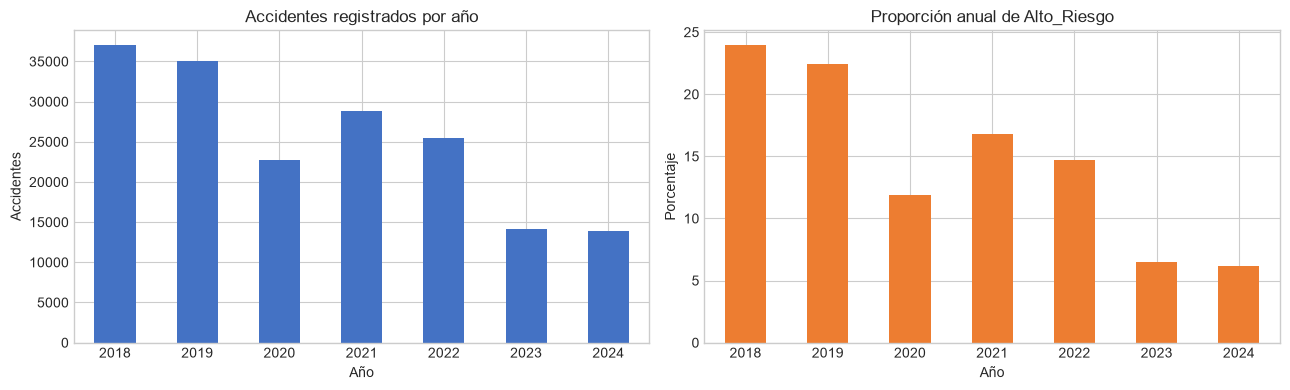

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
distribucion['Accidentes'].plot(kind='bar', ax=axes[0], color='#4472C4')
axes[0].set(title='Accidentes registrados por año', xlabel='Año', ylabel='Accidentes')
axes[0].tick_params(axis='x', rotation=0)

(100 * distribucion['Tasa_Alto_Riesgo']).plot(kind='bar', ax=axes[1], color='#ED7D31')
axes[1].set(title='Proporción anual de Alto_Riesgo', xlabel='Año', ylabel='Porcentaje')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(REPORTS_PATH / '01_distribucion_anual.png', dpi=160, bbox_inches='tight')
plt.show()

### Interpretación requerida

Antes de interpretar el desempeño predictivo se debe observar si el volumen de accidentes y la tasa de `Alto_Riesgo` cambian en 2023–2024. Una caída no prueba por sí sola que exista subregistro: puede reflejar cambios reales, cambios de cobertura, modificaciones en la fuente o sensibilidad de la etiqueta al periodo.

## 3. Carga de modelos y preprocesadores

In [57]:
artifact_files = {
    'preprocesador_logistica': 'preprocesador_logistica.pkl',
    'preprocesador_arboles': 'preprocesador_arboles.pkl',
    'Regresión Logística': 'modelo_logistica.pkl',
    'Random Forest': 'modelo_random_forest.pkl',
    'XGBoost': 'modelo_xgboost.pkl',
}
missing_artifacts = [name for name in artifact_files.values() if not (MODELS_PATH / name).exists()]
assert not missing_artifacts, f'Faltan artefactos: {missing_artifacts}'

pre_log = joblib.load(MODELS_PATH / artifact_files['preprocesador_logistica'])
pre_tree = joblib.load(MODELS_PATH / artifact_files['preprocesador_arboles'])
models = {
    'Regresión Logística': joblib.load(MODELS_PATH / artifact_files['Regresión Logística']),
    'Random Forest': joblib.load(MODELS_PATH / artifact_files['Random Forest']),
    'XGBoost': joblib.load(MODELS_PATH / artifact_files['XGBoost']),
}
print('Artefactos cargados correctamente:', list(models))

Artefactos cargados correctamente: ['Regresión Logística', 'Random Forest', 'XGBoost']


In [58]:
test = dataset.loc[dataset['Periodo'].eq('test')].copy()
X_test = test[feature_cols]
y_test = test['Alto_Riesgo'].astype(int)

X_test_log = pre_log.transform(X_test)
X_test_tree = pre_tree.transform(X_test)

assert X_test_log.shape[0] == len(test)
assert X_test_tree.shape[0] == len(test)
print('Test:', X_test.shape)
print('Preprocesamiento logístico:', X_test_log.shape)
print('Preprocesamiento de árboles:', X_test_tree.shape)

Test: (58480, 12)
Preprocesamiento logístico: (58480, 40)
Preprocesamiento de árboles: (58480, 40)


## 4. Predicciones y línea base

In [59]:
scores = {
    'Regresión Logística': models['Regresión Logística'].predict_proba(X_test_log)[:, 1],
    'Random Forest': models['Random Forest'].predict_proba(X_test_tree)[:, 1],
    'XGBoost': models['XGBoost'].predict_proba(X_test_tree)[:, 1],
}

# Línea base sin capacidad de discriminación: asigna a todos la prevalencia de train.
train_prevalence = dataset.loc[dataset['Periodo'].eq('train'), 'Alto_Riesgo'].mean()
scores['Línea base'] = np.full(len(test), train_prevalence)

predictions = {name: (proba >= 0.5).astype(int) for name, proba in scores.items()}

In [60]:
def classification_metrics(y_true, y_pred, y_score):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'AUC_ROC': roc_auc_score(y_true, y_score) if len(np.unique(y_true)) == 2 else np.nan,
        'Average_Precision': average_precision_score(y_true, y_score),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'Especificidad': tn / (tn + fp) if (tn + fp) else np.nan,
        'Balanced_Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Brier': brier_score_loss(y_true, y_score),
        'Tasa_Predicha_Positiva': np.mean(y_pred),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
    }

comparison = pd.DataFrame({
    name: classification_metrics(y_test, predictions[name], scores[name])
    for name in scores
}).T.sort_values('Average_Precision', ascending=False)

comparison.round(4)

,F1,AUC_ROC,Average_Precision,Precision,Recall,Especificidad,Balanced_Accuracy,Brier,Tasa_Predicha_Positiva,TN,FP,FN,TP
XGBoost,0.1973,0.7053,0.1329,0.1476,0.2972,0.8845,0.5908,0.1264,0.1269,48464.0,6328.0,2592.0,1096.0
Regresión Logística,0.1803,0.6577,0.1128,0.1330,0.2798,0.8772,0.5785,0.1615,0.1327,48063.0,6729.0,2656.0,1032.0
Random Forest,0.1551,0.6506,0.1053,0.1071,0.2809,0.8424,0.5616,0.1714,0.1654,46156.0,8636.0,2652.0,1036.0
Línea base,0.0000,0.5000,0.0631,0.0000,0.0000,1.0000,0.5000,0.0726,0.0000,54792.0,0.0,3688.0,0.0


In [61]:
comparison.to_csv(REPORTS_PATH / 'metricas_globales_umbral_05.csv', encoding='utf-8-sig')
comparison[['F1', 'AUC_ROC', 'Average_Precision', 'Precision', 'Recall', 'Brier']].round(4)

,F1,AUC_ROC,Average_Precision,Precision,Recall,Brier
XGBoost,0.1973,0.7053,0.1329,0.1476,0.2972,0.1264
Regresión Logística,0.1803,0.6577,0.1128,0.1330,0.2798,0.1615
Random Forest,0.1551,0.6506,0.1053,0.1071,0.2809,0.1714
Línea base,0.0000,0.5000,0.0631,0.0000,0.0000,0.0726


### Criterio de lectura

Debido al desbalance de clases, `Average_Precision` y la curva Precision-Recall son especialmente relevantes. El AUC-ROC mide ordenamiento general, mientras que precisión y recall describen el comportamiento de las alertas con el umbral 0,5. Un modelo útil debe superar claramente la línea base y evaluarse según el costo operativo de falsas alertas y casos omitidos.

## 5. Matrices de confusión

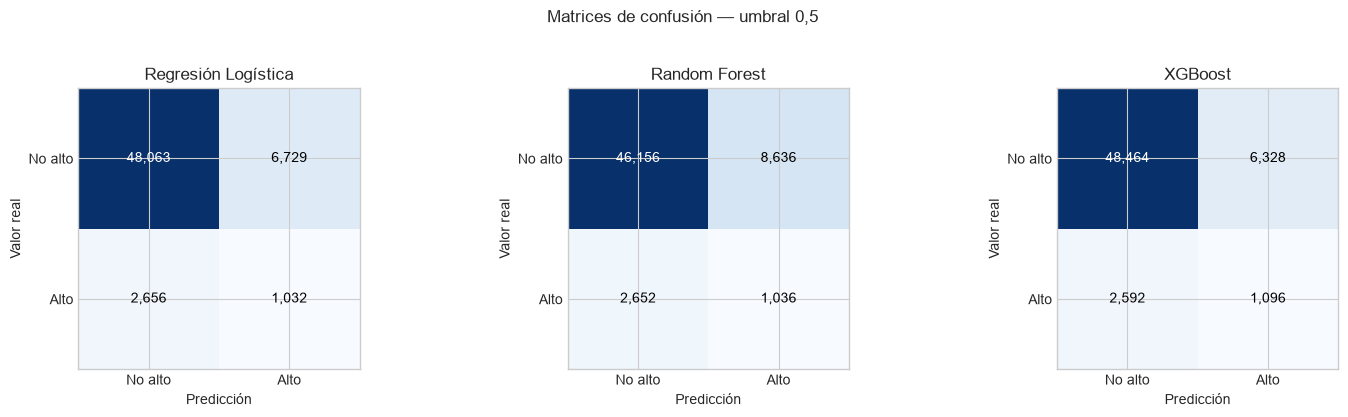

In [ ]:
model_names = ['Regresión Logística', 'Random Forest', 'XGBoost']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, predictions[name], labels=[0, 1])
    image = ax.imshow(cm, cmap='Blues')
    limit = cm.max() / 2
    for row in range(2):
        for col in range(2):
            ax.text(col, row, f'{cm[row, col]:,}', ha='center', va='center',
                    color='white' if cm[row, col] > limit else 'black')
    ax.set(title=name, xlabel='Predicción', ylabel='Valor real')
    ax.set_xticks([0, 1], labels=['No alto', 'Alto'])
    ax.set_yticks([0, 1], labels=['No alto', 'Alto'])
plt.suptitle('Matrices de confusión — umbral 0,5', y=1.03)
plt.tight_layout()
plt.savefig(REPORTS_PATH / '02_matrices_confusion.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Curvas ROC y Precision-Recall

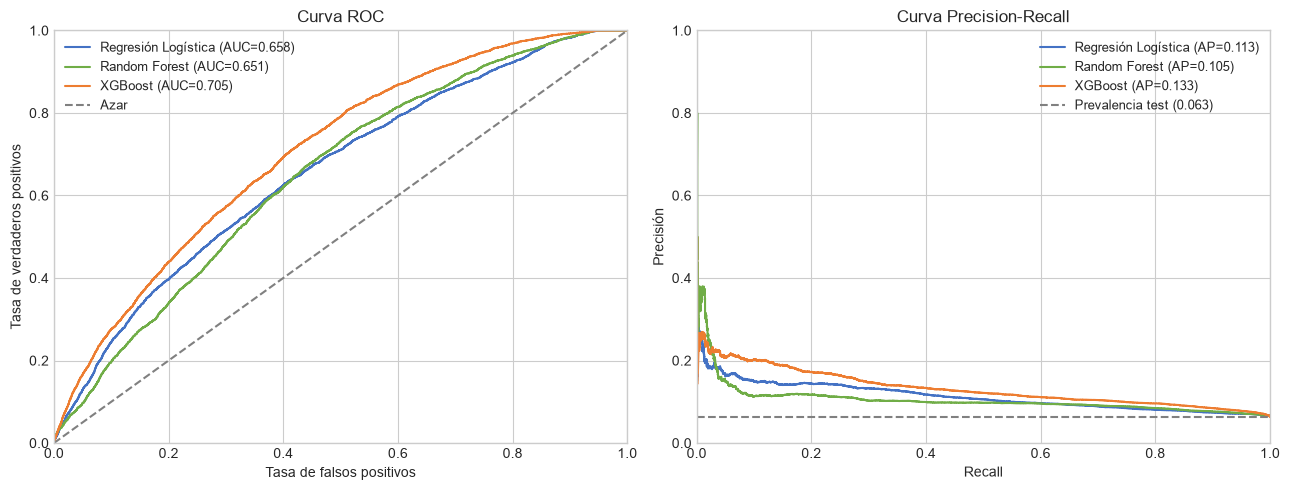

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {'Regresión Logística': '#4472C4', 'Random Forest': '#70AD47', 'XGBoost': '#ED7D31'}
for name in model_names:
    fpr, tpr, _ = roc_curve(y_test, scores[name])
    precision, recall, _ = precision_recall_curve(y_test, scores[name])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, scores[name]):.3f})", color=colors[name])
    axes[1].plot(recall, precision, label=f"{name} (AP={average_precision_score(y_test, scores[name]):.3f})", color=colors[name])

axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Azar')
axes[0].set(title='Curva ROC', xlabel='Tasa de falsos positivos', ylabel='Tasa de verdaderos positivos')
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label=f'Prevalencia test ({y_test.mean():.3f})')
axes[1].set(title='Curva Precision-Recall', xlabel='Recall', ylabel='Precisión')
for ax in axes:
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(REPORTS_PATH / '03_curvas_roc_pr.png', dpi=160, bbox_inches='tight')
plt.show()

## 7. Calibración de probabilidades

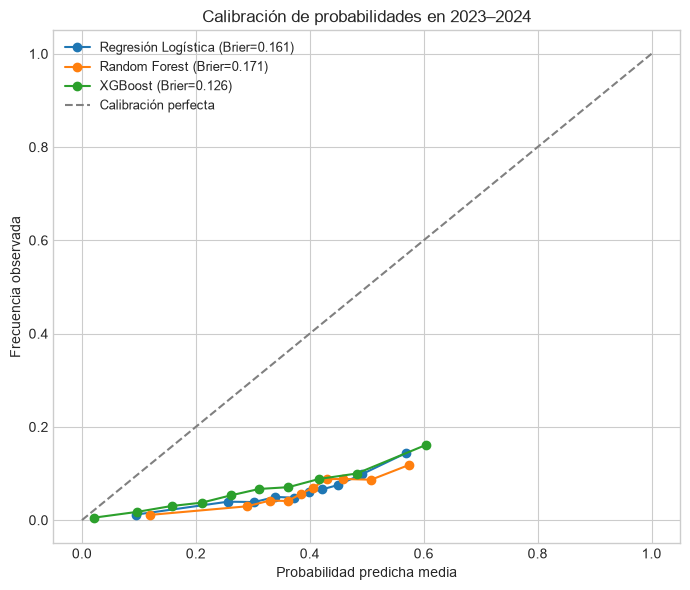

In [64]:
plt.figure(figsize=(7, 6))
for name in model_names:
    frac_pos, mean_pred = calibration_curve(y_test, scores[name], n_bins=10, strategy='quantile')
    plt.plot(mean_pred, frac_pos, marker='o', label=f"{name} (Brier={brier_score_loss(y_test, scores[name]):.3f})")
plt.plot([0, 1], [0, 1], '--', color='gray', label='Calibración perfecta')
plt.xlabel('Probabilidad predicha media')
plt.ylabel('Frecuencia observada')
plt.title('Calibración de probabilidades en 2023–2024')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS_PATH / '04_calibracion.png', dpi=160, bbox_inches='tight')
plt.show()

Una curva alejada de la diagonal indica que las probabilidades no corresponden bien con las frecuencias observadas. El uso de `class_weight` y `scale_pos_weight` puede mejorar la detección de la clase minoritaria, pero también puede afectar la calibración. Si el dashboard mostrará probabilidades, debe evaluarse una calibración posterior usando exclusivamente datos de validación temporal.

## 8. Estabilidad por año

In [65]:
test['Anio'] = test['Fecha_Acc'].dt.year
year_rows = []
for year, idx in test.groupby('Anio').groups.items():
    for name in model_names:
        metrics = classification_metrics(
            y_test.loc[idx], predictions[name][test.index.get_indexer(idx)], scores[name][test.index.get_indexer(idx)]
        )
        year_rows.append({'Anio': year, 'Modelo': name, **metrics})
metrics_by_year = pd.DataFrame(year_rows)
metrics_by_year[['Anio', 'Modelo', 'F1', 'AUC_ROC', 'Average_Precision', 'Precision', 'Recall']].round(4)

,Anio,Modelo,F1,AUC_ROC,Average_Precision,Precision,Recall
0,2023,Regresión Logística,0.1829,0.6599,0.1162,0.1359,0.2797
1,2023,Random Forest,0.1551,0.6479,0.1079,0.1073,0.2792
2,2023,XGBoost,0.1935,0.7005,0.1357,0.1461,0.2866
3,2024,Regresión Logística,0.1776,0.6553,0.1098,0.1300,0.2799
4,2024,Random Forest,0.1551,0.6533,0.1034,0.1069,0.2827
5,2024,XGBoost,0.2011,0.7100,0.1308,0.1492,0.3083


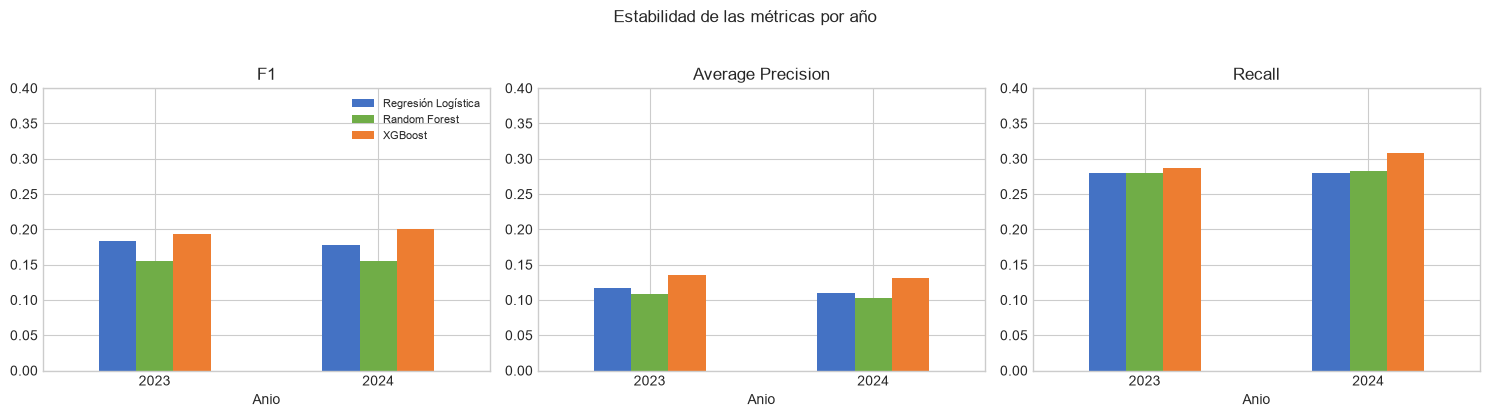

In [66]:
metrics_by_year.to_csv(REPORTS_PATH / 'metricas_por_anio.csv', index=False, encoding='utf-8-sig')
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['F1', 'Average_Precision', 'Recall']):
    pivot = metrics_by_year.pivot(index='Anio', columns='Modelo', values=metric)
    pivot[model_names].plot(kind='bar', ax=ax, color=[colors[name] for name in model_names])
    ax.set_title(metric.replace('_', ' '))
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylim(0, max(0.4, metrics_by_year[metric].max() * 1.15))
    if ax is not axes[0]: ax.get_legend().remove()
axes[0].legend(fontsize=8, loc='upper right')
plt.suptitle('Estabilidad de las métricas por año', y=1.03)
plt.tight_layout()
plt.savefig(REPORTS_PATH / '05_metricas_por_anio.png', dpi=160, bbox_inches='tight')
plt.show()

## 9. Diagnóstico de umbral para XGBoost

El umbral 0,5 no necesariamente representa el mejor compromiso operativo. La siguiente exploración usa 2023 para escoger, de forma diagnóstica, el umbral con mayor F1 y luego informa su comportamiento en 2024. Esto no convierte 2024 en una prueba completamente independiente, porque los algoritmos ya fueron comparados previamente con 2023–2024. El umbral definitivo debe fijarse mediante validación temporal dentro de 2018–2022.

In [67]:
score_xgb = scores['XGBoost']
mask_2023 = test['Anio'].eq(2023).to_numpy()
mask_2024 = test['Anio'].eq(2024).to_numpy()
thresholds = np.linspace(0.05, 0.95, 181)
threshold_rows = []
for threshold in thresholds:
    pred_2023 = (score_xgb[mask_2023] >= threshold).astype(int)
    threshold_rows.append({
        'Umbral': threshold,
        'F1_2023': f1_score(y_test.to_numpy()[mask_2023], pred_2023, zero_division=0),
        'Precision_2023': precision_score(y_test.to_numpy()[mask_2023], pred_2023, zero_division=0),
        'Recall_2023': recall_score(y_test.to_numpy()[mask_2023], pred_2023, zero_division=0),
    })
threshold_results = pd.DataFrame(threshold_rows)
best_threshold = float(threshold_results.loc[threshold_results['F1_2023'].idxmax(), 'Umbral'])
pred_2024_default = (score_xgb[mask_2024] >= 0.5).astype(int)
pred_2024_diagnostic = (score_xgb[mask_2024] >= best_threshold).astype(int)

threshold_comparison_2024 = pd.DataFrame({
    'Umbral 0.5': classification_metrics(y_test.to_numpy()[mask_2024], pred_2024_default, score_xgb[mask_2024]),
    f'Umbral diagnóstico {best_threshold:.3f}': classification_metrics(
        y_test.to_numpy()[mask_2024], pred_2024_diagnostic, score_xgb[mask_2024]
    ),
}).T
print(f'Umbral con mayor F1 en 2023: {best_threshold:.3f}')
threshold_comparison_2024[['F1', 'Precision', 'Recall', 'Especificidad', 'Tasa_Predicha_Positiva']].round(4)

Umbral con mayor F1 en 2023: 0.455


,F1,Precision,Recall,Especificidad,Tasa_Predicha_Positiva
Umbral 0.5,0.2011,0.1492,0.3083,0.8851,0.1268
Umbral diagnóstico 0.455,0.2025,0.1349,0.4062,0.8296,0.1848


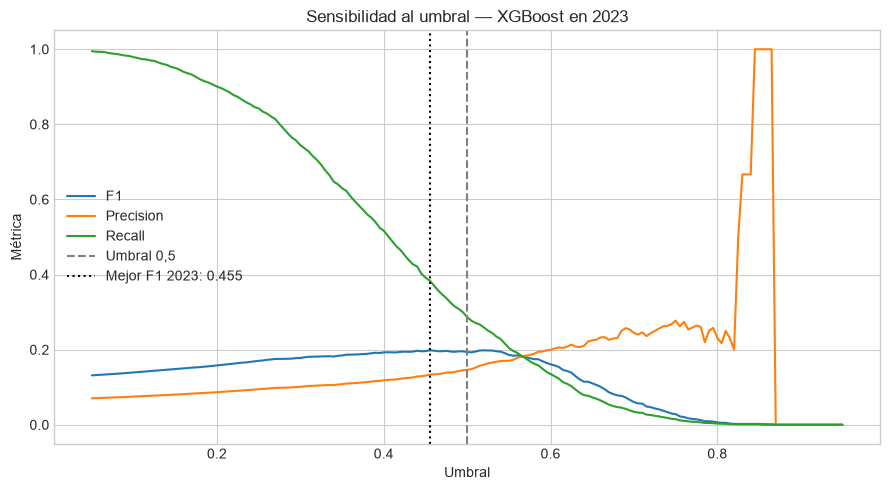

In [68]:
plt.figure(figsize=(9, 5))
for metric in ['F1_2023', 'Precision_2023', 'Recall_2023']:
    plt.plot(threshold_results['Umbral'], threshold_results[metric], label=metric.replace('_2023', ''))
plt.axvline(0.5, linestyle='--', color='gray', label='Umbral 0,5')
plt.axvline(best_threshold, linestyle=':', color='black', label=f'Mejor F1 2023: {best_threshold:.3f}')
plt.xlabel('Umbral')
plt.ylabel('Métrica')
plt.title('Sensibilidad al umbral — XGBoost en 2023')
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_PATH / '06_umbral_xgboost_2023.png', dpi=160, bbox_inches='tight')
plt.show()

## 10. Errores por localidad y franja horaria

In [69]:
evaluation_xgb = test[['Fecha_Acc', 'Anio', 'Localidad', 'Franja_Horaria', 'Alto_Riesgo']].copy()
evaluation_xgb['Probabilidad'] = score_xgb
evaluation_xgb['Prediccion'] = predictions['XGBoost']
evaluation_xgb['Error'] = np.select(
    [
        (evaluation_xgb['Alto_Riesgo'] == 0) & (evaluation_xgb['Prediccion'] == 1),
        (evaluation_xgb['Alto_Riesgo'] == 1) & (evaluation_xgb['Prediccion'] == 0),
    ],
    ['Falso positivo', 'Falso negativo'],
    default='Acierto'
)
evaluation_xgb['Error'].value_counts()

Error
Acierto           49560
Falso positivo     6328
Falso negativo     2592
Name: count, dtype: int64

In [70]:
def subgroup_metrics(frame, group_col):
    rows = []
    for group, part in frame.groupby(group_col):
        if part['Alto_Riesgo'].nunique() < 2:
            auc = np.nan
        else:
            auc = roc_auc_score(part['Alto_Riesgo'], part['Probabilidad'])
        rows.append({
            group_col: group,
            'Observaciones': len(part),
            'Casos_Positivos': int(part['Alto_Riesgo'].sum()),
            'Prevalencia': part['Alto_Riesgo'].mean(),
            'F1': f1_score(part['Alto_Riesgo'], part['Prediccion'], zero_division=0),
            'Precision': precision_score(part['Alto_Riesgo'], part['Prediccion'], zero_division=0),
            'Recall': recall_score(part['Alto_Riesgo'], part['Prediccion'], zero_division=0),
            'AUC_ROC': auc,
            'Average_Precision': average_precision_score(part['Alto_Riesgo'], part['Probabilidad']),
        })
    return pd.DataFrame(rows)

by_locality = subgroup_metrics(evaluation_xgb, 'Localidad').sort_values('F1', ascending=False)
by_slot = subgroup_metrics(evaluation_xgb, 'Franja_Horaria').sort_values('F1', ascending=False)
by_locality.to_csv(REPORTS_PATH / 'metricas_xgboost_por_localidad.csv', index=False, encoding='utf-8-sig')
by_slot.to_csv(REPORTS_PATH / 'metricas_xgboost_por_franja.csv', index=False, encoding='utf-8-sig')
display(by_locality.round(4))
display(by_slot.round(4))

,Localidad,Observaciones,Casos_Positivos,Prevalencia,F1,Precision,Recall,AUC_ROC,Average_Precision
4,CHAPINERO,2924,181,0.0619,0.2872,0.2068,0.4696,0.7879,0.2195
16,TEUSAQUILLO,2924,223,0.0763,0.2853,0.2112,0.4395,0.7270,0.1821
5,CIUDAD BOLÍVAR,2924,389,0.1330,0.2490,0.1543,0.6452,0.5994,0.1908
8,KENNEDY,2924,197,0.0674,0.2439,0.1605,0.5076,0.7066,0.1545
1,BARRIOS UNIDOS,2924,158,0.0540,0.2093,0.1654,0.2848,0.7493,0.1402
19,USME,2924,236,0.0807,0.2049,0.1603,0.2839,0.6163,0.1354
11,RAFAEL URIBE URIBE,2924,288,0.0985,0.1943,0.1377,0.3299,0.5851,0.1492
17,TUNJUELITO,2924,227,0.0776,0.1881,0.1345,0.3128,0.6538,0.1277
9,LOS MÁRTIRES,2924,247,0.0845,0.1765,0.1386,0.2429,0.6231,0.1239
12,SAN CRISTÓBAL,2924,320,0.1094,0.1738,0.1324,0.2531,0.5666,0.1338


,Franja_Horaria,Observaciones,Casos_Positivos,Prevalencia,F1,Precision,Recall,AUC_ROC,Average_Precision
0,Madrugada,14620,1633,0.1117,0.2746,0.1879,0.5101,0.6839,0.1889
3,Tarde,14620,617,0.0422,0.1203,0.0912,0.1767,0.6892,0.0815
1,Mañana,14620,673,0.0460,0.0985,0.0857,0.1159,0.6959,0.0817
2,Noche,14620,765,0.0523,0.0921,0.0859,0.0993,0.6229,0.0773


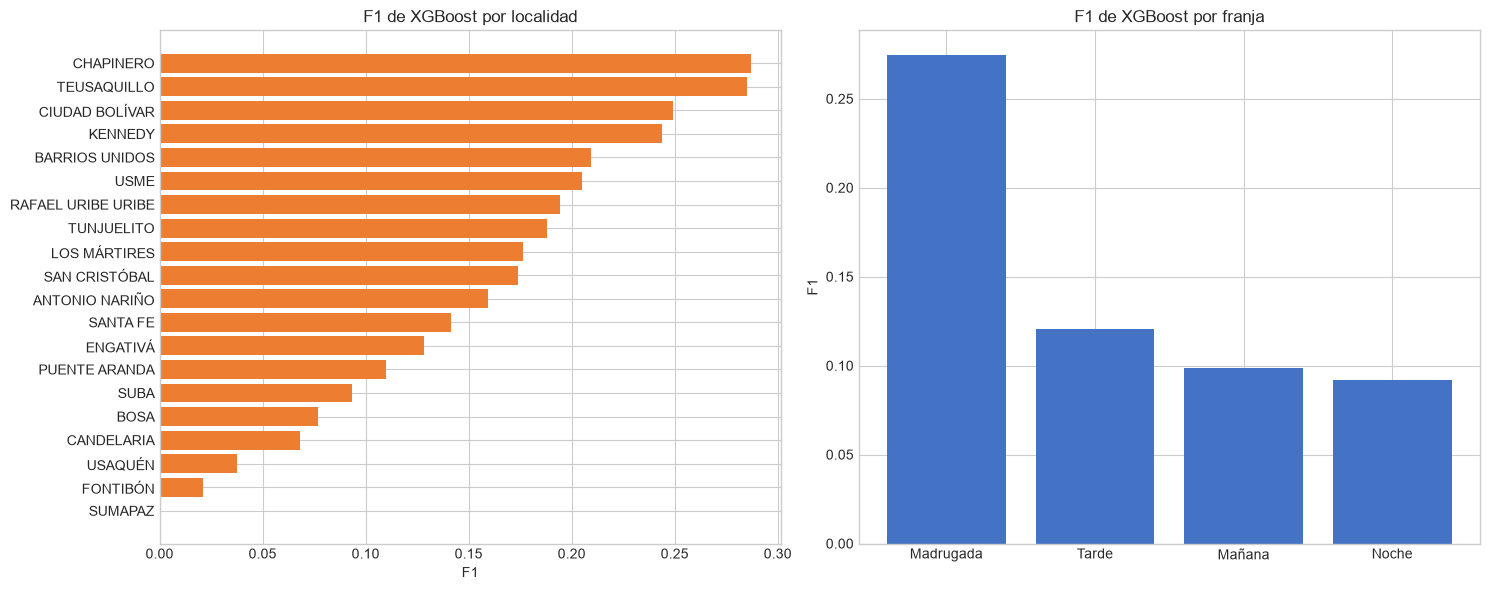

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_locality = by_locality.sort_values('F1')
axes[0].barh(plot_locality['Localidad'], plot_locality['F1'], color='#ED7D31')
axes[0].set(title='F1 de XGBoost por localidad', xlabel='F1', ylabel='')
axes[1].bar(by_slot['Franja_Horaria'], by_slot['F1'], color='#4472C4')
axes[1].set(title='F1 de XGBoost por franja', xlabel='', ylabel='F1')
plt.tight_layout()
plt.savefig(REPORTS_PATH / '07_desempeno_subgrupos_xgboost.png', dpi=160, bbox_inches='tight')
plt.show()

Las comparaciones entre subgrupos deben leerse junto con `Casos_Positivos` y `Prevalencia`. Un F1 bajo puede reflejar pocos positivos, cambio de distribución o una frontera de decisión inadecuada; no demuestra por sí solo que una localidad sea más o menos segura.

## 11. Importancia de variables en XGBoost

In [72]:
feature_names = pre_tree.get_feature_names_out()
importances = models['XGBoost'].feature_importances_
assert len(feature_names) == len(importances)

feature_importance = (
    pd.DataFrame({'Variable': feature_names, 'Importancia': importances})
    .sort_values('Importancia', ascending=False)
)
feature_importance.to_csv(REPORTS_PATH / 'importancia_variables_xgboost.csv', index=False, encoding='utf-8-sig')
feature_importance.head(20).round(4)

,Variable,Importancia
15,cat__Localidad_SUMAPAZ,0.3920
5,cat__Localidad_CIUDAD BOLÍVAR,0.0549
27,cat__Dia_Semana_Sunday,0.0458
33,remainder__Es_Festivo,0.0372
20,cat__Franja_Horaria_Madrugada,0.0371
3,cat__Localidad_CANDELARIA,0.0347
35,remainder__Accidentes_Prom_30d,0.0225
2,cat__Localidad_BOSA,0.0220
9,cat__Localidad_LOS MÁRTIRES,0.0201
10,cat__Localidad_PUENTE ARANDA,0.0199


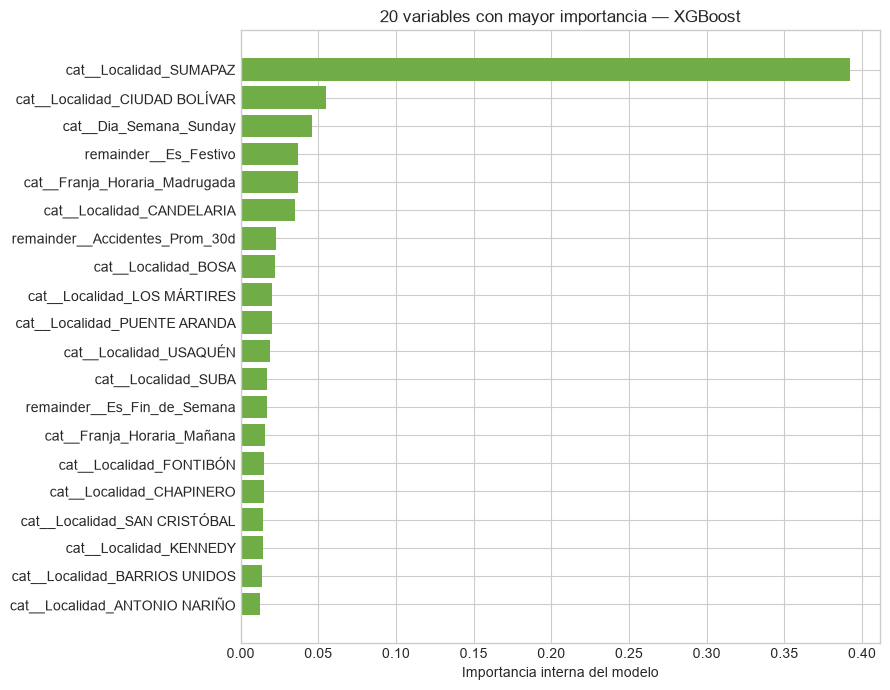

In [73]:
top_features = feature_importance.head(20).sort_values('Importancia')
plt.figure(figsize=(9, 7))
plt.barh(top_features['Variable'], top_features['Importancia'], color='#70AD47')
plt.xlabel('Importancia interna del modelo')
plt.ylabel('')
plt.title('20 variables con mayor importancia — XGBoost')
plt.tight_layout()
plt.savefig(REPORTS_PATH / '08_importancia_xgboost.png', dpi=160, bbox_inches='tight')
plt.show()

La importancia interna indica cuánto utilizó XGBoost una variable, pero no expresa causalidad ni el sentido del efecto. Para una explicación más rigurosa pueden incorporarse posteriormente importancia por permutación o valores SHAP, calculados sobre una muestra representativa para controlar el costo computacional.

## 12. Exportación del detalle de evaluación

In [74]:
evaluation_xgb.to_parquet(REPORTS_PATH / 'predicciones_xgboost_2023_2024.parquet', index=False)
print('Resultados guardados en:', REPORTS_PATH.resolve())
for path in sorted(REPORTS_PATH.iterdir()):
    print('-', path.name)

Resultados guardados en: /Users/camilo/Library/CloudStorage/OneDrive-FundaciónUniversitariaKonradLorenz/Siniestralidad_Vial/reports/evaluation
- 01_distribucion_anual.png
- 02_matrices_confusion.png
- 03_curvas_roc_pr.png
- 04_calibracion.png
- 05_metricas_por_anio.png
- 06_umbral_xgboost_2023.png
- 07_desempeno_subgrupos_xgboost.png
- 08_importancia_xgboost.png
- 09_errores_por_franja.png
- 10_validacion_temporal_2018_2022.png
- 11_umbral_validacion_temporal.png
- calibracion_modelos.csv
- comparacion_territorial_xgboost.csv
- comparacion_umbrales_xgboost_2024.csv
- conclusion_ejecutiva.md
- confirmacion_retrospectiva_modelo_umbral_temporal.csv
- diagnostico_umbrales_xgboost_2023.csv
- errores_xgboost_por_franja.csv
- importancia_permutacion_xgboost.csv
- importancia_variables_xgboost.csv
- metricas_globales_umbral_05.csv
- metricas_macro_localidad.csv
- metricas_por_anio.csv
- metricas_xgboost_por_franja.csv
- metricas_xgboost_por_localidad.csv
- predicciones_validacion_temporal_202

## 13. Exportación ampliada del diagnóstico de umbrales
Análisis exploratorio: 0,455 procede de la selección con 2023, no es un umbral definitivo. Se conserva la búsqueda completa y se compara explícitamente 0,5 frente a 0,455 en 2024.

In [75]:
threshold_results = pd.DataFrame([
    {'Umbral': float(t), **classification_metrics(y_test.to_numpy()[mask_2023],
      (score_xgb[mask_2023] >= t).astype(int), score_xgb[mask_2023])}
    for t in thresholds
])
threshold_results.to_csv(REPORTS_PATH / 'diagnostico_umbrales_xgboost_2023.csv', index=False)
threshold_comparison_2024 = pd.DataFrame([
    {'Umbral': t, **classification_metrics(y_test.to_numpy()[mask_2024],
      (score_xgb[mask_2024] >= t).astype(int), score_xgb[mask_2024])}
    for t in [0.5, 0.455]
])
threshold_comparison_2024.to_csv(REPORTS_PATH / 'comparacion_umbrales_xgboost_2024.csv', index=False)
delta_fp = int(threshold_comparison_2024.iloc[1].FP - threshold_comparison_2024.iloc[0].FP)
delta_tp = int(threshold_comparison_2024.iloc[1].TP - threshold_comparison_2024.iloc[0].TP)
ratio_alertas = delta_fp / delta_tp if delta_tp > 0 else np.nan
display(threshold_comparison_2024.round(4))
print(f'FP adicionales: {delta_fp}; positivos adicionales detectados: {delta_tp}; FP por TP adicional: {ratio_alertas:.2f}')

,Umbral,F1,AUC_ROC,Average_Precision,Precision,Recall,Especificidad,Balanced_Accuracy,Brier,Tasa_Predicha_Positiva,TN,FP,FN,TP
0,0.500,0.2011,0.71,0.1308,0.1492,0.3083,0.8851,0.5967,0.1253,0.1268,24324,3159,1243,554
1,0.455,0.2025,0.71,0.1308,0.1349,0.4062,0.8296,0.6179,0.1253,0.1848,22801,4682,1067,730


FP adicionales: 1523; positivos adicionales detectados: 176; FP por TP adicional: 8.65


TP = verdaderos positivos; FP = falsos positivos; FN = falsos negativos; TN = verdaderos negativos. La razón incremental describe el costo en falsas alertas de aumentar la detección. Maximizar F1 no incorpora los costos operativos; el umbral debe seleccionarse con validación temporal y un criterio de intervención explícito.

## 14. Tabla de calibración y comparación con prevalencia

In [76]:
calibration_rows = []
for name in model_names:
    prob = np.asarray(scores[name])
    edges = np.percentile(prob, np.linspace(0, 100, 11))
    bins = np.searchsorted(edges[1:-1], prob)
    for group in np.unique(bins):
        selected = bins == group
        calibration_rows.append({'Modelo': name, 'Grupo': int(group + 1),
            'Score_Min': float(prob[selected].min()), 'Score_Max': float(prob[selected].max()),
            'Probabilidad_Predicha_Media': float(prob[selected].mean()),
            'Frecuencia_Observada': float(y_test.to_numpy()[selected].mean()),
            'Observaciones': int(selected.sum())})
calibration_table = pd.DataFrame(calibration_rows)
calibration_table.to_csv(REPORTS_PATH / 'calibracion_modelos.csv', index=False)
score_summary = pd.DataFrame([{'Modelo': name, 'Score_Medio': np.mean(prob),
    'Prevalencia_Test': y_test.mean(), 'Prevalencia_Train': train_prevalence,
    'Brier': brier_score_loss(y_test, prob)} for name, prob in scores.items()])
score_summary.to_csv(REPORTS_PATH / 'resumen_calibracion_modelos.csv', index=False)
display(calibration_table.round(4))
display(score_summary.round(4))
assert calibration_table.groupby('Modelo').Observaciones.sum().eq(len(test)).all()

,Modelo,Grupo,Score_Min,Score_Max,Probabilidad_Predicha_Media,Frecuencia_Observada,Observaciones
0,Regresión Logística,1,0.0014,0.2217,0.0948,0.0118,5848
1,Regresión Logística,2,0.2217,0.2828,0.2563,0.0395,5848
2,Regresión Logística,3,0.2828,0.3214,0.3028,0.0388,5849
3,Regresión Logística,4,0.3214,0.3569,0.3396,0.0498,5847
4,Regresión Logística,5,0.3569,0.3853,0.3718,0.0481,5848
5,Regresión Logística,6,0.3853,0.4102,0.3978,0.0595,5848
6,Regresión Logística,7,0.4102,0.4343,0.4220,0.0660,5848
7,Regresión Logística,8,0.4343,0.4665,0.4495,0.0752,5848
8,Regresión Logística,9,0.4665,0.5209,0.4914,0.0983,5848
9,Regresión Logística,10,0.5209,0.7450,0.5687,0.1436,5848


,Modelo,Score_Medio,Prevalencia_Test,Prevalencia_Train,Brier
0,Regresión Logística,0.3695,0.0631,0.1793,0.1615
1,Random Forest,0.3860,0.0631,0.1793,0.1714
2,XGBoost,0.2923,0.0631,0.1793,0.1264
3,Línea base,0.1793,0.0631,0.1793,0.0726


Los grupos usan los mismos límites por cuantiles que la curva existente; los empates pueden generar tamaños diferentes o grupos vacíos. `predict_proba` no garantiza calibración, especialmente con `class_weight` o `scale_pos_weight`. El Brier de la línea base constante también está afectado por el cambio de prevalencia: utiliza la frecuencia de entrenamiento, no la de prueba.

Las puntuaciones de XGBoost no deben mostrarse todavía como probabilidades literales en el dashboard. Se recomienda provisionalmente una puntuación o nivel relativo de riesgo, aclarando que mide superar un umbral histórico y no riesgo individual. La calibración posterior requiere validación temporal independiente del ajuste del modelo.

## 15. Sensibilidad a la inclusión de Sumapaz

In [77]:
sumapaz_mask = test.Localidad.eq('SUMAPAZ').to_numpy()
sensitivity_sumapaz = pd.DataFrame([
    {'Escenario': label, 'Observaciones': int(mask.sum()),
     'Positivos': int(y_test.to_numpy()[mask].sum()),
     **classification_metrics(y_test.to_numpy()[mask], predictions['XGBoost'][mask], score_xgb[mask])}
    for label, mask in [('Todas las localidades', np.ones(len(test), dtype=bool)),
                         ('Sin Sumapaz', ~sumapaz_mask)]
])
sensitivity_sumapaz.to_csv(REPORTS_PATH / 'sensibilidad_sumapaz.csv', index=False)
print('Sumapaz:', int(sumapaz_mask.sum()), 'observaciones;', int(y_test.to_numpy()[sumapaz_mask].sum()), 'positivos')
display(sensitivity_sumapaz.round(4))

Sumapaz: 2924 observaciones; 2 positivos


,Escenario,Observaciones,Positivos,F1,AUC_ROC,Average_Precision,Precision,Recall,Especificidad,Balanced_Accuracy,Brier,Tasa_Predicha_Positiva,TN,FP,FN,TP
0,Todas las localidades,58480,3688,0.1973,0.7053,0.1329,0.1476,0.2972,0.8845,0.5908,0.1264,0.1269,48464,6328,2592,1096
1,Sin Sumapaz,55556,3686,0.1973,0.6891,0.1330,0.1476,0.2973,0.8780,0.5877,0.1330,0.1336,45542,6328,2590,1096


Se evalúa el mismo modelo en dos poblaciones; no se elimina Sumapaz del entrenamiento. Su importancia elevada no indica concentración de riesgo ni porcentaje de accidentes explicado. Puede ayudar a identificar un grupo casi siempre negativo. El cambio de métricas también refleja la composición de la población evaluada.

## 16. Sensibilidad experimental: XGBoost sin Localidad
Único entrenamiento adicional autorizado. Se clonan los hiperparámetros originales y se ajusta un preprocesador independiente solo en 2018–2022. La etiqueta y los predictores históricos conservan su definición; no se guarda ni reemplaza ningún modelo. Evaluación exploratoria sobre 2023–2024, ya consultado durante el desarrollo.

In [78]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

train = dataset.loc[dataset.Periodo.eq('train')].copy()
features_no_locality = [c for c in feature_cols if c != 'Localidad']
pre_no_locality = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['Franja_Horaria', 'Dia_Semana'])
], remainder='passthrough')
X_train_no_locality = pre_no_locality.fit_transform(train[features_no_locality])
X_test_no_locality = pre_no_locality.transform(test[features_no_locality])
experimental_xgb = clone(models['XGBoost'])
experimental_xgb.fit(X_train_no_locality, train.Alto_Riesgo)
score_no_locality = experimental_xgb.predict_proba(X_test_no_locality)[:, 1]
sensitivity_no_locality = pd.DataFrame([
    {'Modelo': label, **classification_metrics(y_test, (prob >= .5).astype(int), prob)}
    for label, prob in [('Original', score_xgb), ('Experimental sin Localidad', score_no_locality)]
])
sensitivity_no_locality.to_csv(REPORTS_PATH / 'sensibilidad_sin_localidad.csv', index=False)
display(sensitivity_no_locality.round(4))
print('Diferencias experimental menos original:')
display(sensitivity_no_locality.set_index('Modelo').diff().iloc[1].round(4))

,Modelo,F1,AUC_ROC,Average_Precision,Precision,Recall,Especificidad,Balanced_Accuracy,Brier,Tasa_Predicha_Positiva,TN,FP,FN,TP
0,Original,0.1973,0.7053,0.1329,0.1476,0.2972,0.8845,0.5908,0.1264,0.1269,48464,6328,2592,1096
1,Experimental sin Localidad,0.1347,0.5887,0.0798,0.0859,0.3118,0.7768,0.5443,0.1754,0.2288,42561,12231,2538,1150


Diferencias experimental menos original:


F1                          -0.0625
AUC_ROC                     -0.1166
Average_Precision           -0.0531
Precision                   -0.0617
Recall                       0.0146
Especificidad               -0.1077
Balanced_Accuracy           -0.0465
Brier                        0.0490
Tasa_Predicha_Positiva       0.1019
TN                       -5903.0000
FP                        5903.0000
FN                         -54.0000
TP                          54.0000
Name: Experimental sin Localidad, dtype: float64

La diferencia mide sensibilidad a la variable explícita Localidad bajo esta configuración, no un efecto causal ni una proporción exacta de desempeño territorial. Los históricos siguen calculados por localidad–franja y la etiqueta conserva umbrales territoriales, por lo que todavía queda información territorial indirecta. No se seleccionan hiperparámetros ni se sustituye el modelo original a partir de esta comparación.

## 17. Promedios macro y extremos territoriales

In [79]:
macro_cols = ['F1', 'Precision', 'Recall', 'AUC_ROC', 'Average_Precision']
macro_summary = pd.DataFrame([{'Metrica': metric,
    'Global': comparison.loc['XGBoost', metric],
    'Macro_No_Ponderado': by_locality[metric].mean(),
    'Localidades_Validas': int(by_locality[metric].notna().sum())}
    for metric in macro_cols])
macro_summary.to_csv(REPORTS_PATH / 'metricas_macro_localidad.csv', index=False)
display(macro_summary.round(4))
print('Localidades sin AUC calculable:', by_locality.loc[by_locality.AUC_ROC.isna(), 'Localidad'].tolist())
territorial = by_locality.copy()
territorial['Pocos_Positivos_Menos_100'] = territorial.Casos_Positivos < 100
rank_rows = []
for metric in ['F1', 'Recall']:
    for label, frame in [('Mejores', territorial.nlargest(5, metric)), ('Peores', territorial.nsmallest(5, metric))]:
        print(metric, label)
        display(frame[['Localidad', metric, 'Casos_Positivos', 'Prevalencia', 'Pocos_Positivos_Menos_100']])
        rank_rows.append(frame.assign(Criterio=metric, Grupo=label))
pd.concat(rank_rows).to_csv(REPORTS_PATH / 'comparacion_territorial_xgboost.csv', index=False)
display(territorial.loc[territorial.Localidad.isin(['SUMAPAZ','USAQUÉN','FONTIBÓN'])])

,Metrica,Global,Macro_No_Ponderado,Localidades_Validas
0,F1,0.1973,0.1524,20
1,Precision,0.1476,0.1224,20
2,Recall,0.2972,0.2328,20
3,AUC_ROC,0.7053,0.6311,20
4,Average_Precision,0.1329,0.1106,20


Localidades sin AUC calculable: []
F1 Mejores


,Localidad,F1,Casos_Positivos,Prevalencia,Pocos_Positivos_Menos_100
4,CHAPINERO,0.287162,181,0.061902,False
16,TEUSAQUILLO,0.285298,223,0.076265,False
5,CIUDAD BOLÍVAR,0.249008,389,0.133037,False
8,KENNEDY,0.243902,197,0.067373,False
1,BARRIOS UNIDOS,0.209302,158,0.054036,False


F1 Peores


,Localidad,F1,Casos_Positivos,Prevalencia,Pocos_Positivos_Menos_100
15,SUMAPAZ,0.000000,2,0.000684,True
7,FONTIBÓN,0.021277,66,0.022572,True
18,USAQUÉN,0.037736,38,0.012996,True
3,CANDELARIA,0.068182,167,0.057114,False
2,BOSA,0.076655,135,0.046170,False


Recall Mejores


,Localidad,Recall,Casos_Positivos,Prevalencia,Pocos_Positivos_Menos_100
5,CIUDAD BOLÍVAR,0.645244,389,0.133037,False
8,KENNEDY,0.507614,197,0.067373,False
4,CHAPINERO,0.469613,181,0.061902,False
16,TEUSAQUILLO,0.439462,223,0.076265,False
11,RAFAEL URIBE URIBE,0.329861,288,0.098495,False


Recall Peores


,Localidad,Recall,Casos_Positivos,Prevalencia,Pocos_Positivos_Menos_100
15,SUMAPAZ,0.000000,2,0.000684,True
7,FONTIBÓN,0.015152,66,0.022572,True
18,USAQUÉN,0.026316,38,0.012996,True
3,CANDELARIA,0.053892,167,0.057114,False
2,BOSA,0.081481,135,0.046170,False


,Localidad,Observaciones,Casos_Positivos,Prevalencia,F1,Precision,Recall,AUC_ROC,Average_Precision,Pocos_Positivos_Menos_100
18,USAQUÉN,2924,38,0.012996,0.037736,0.066667,0.026316,0.645507,0.026727,True
7,FONTIBÓN,2924,66,0.022572,0.021277,0.035714,0.015152,0.643038,0.044543,True
15,SUMAPAZ,2924,2,0.000684,0.000000,0.000000,0.000000,0.365332,0.000785,True


La métrica global se calcula reuniendo las predicciones: los grupos con más positivos pesan más en recall y aquellos con más alertas en precisión; AUC también compara pares entre localidades. No equivale a un promedio simple de métricas territoriales. El promedio macro asigna igual peso a cada localidad. Para AUC se excluyen únicamente los grupos sin ambas clases de su promedio.

Sumapaz, Usaquén y Fontibón requieren cautela por su escaso número de positivos. La marca de menos de 100 es descriptiva, no un umbral de significancia estadística. Estas métricas evalúan el modelo y no constituyen indicadores de seguridad territorial.

## 18. Conteos de errores por franja

,Franja_Horaria,Observaciones,Positivos_Reales,F1,AUC_ROC,Average_Precision,Precision,Recall,Especificidad,Balanced_Accuracy,Brier,Tasa_Predicha_Positiva,TN,FP,FN,TP
0,Madrugada,14620,1633,0.2746,0.6839,0.1889,0.1879,0.5101,0.7227,0.6164,0.1844,0.3033,9386,3601,800,833
1,Mañana,14620,673,0.0985,0.6959,0.0817,0.0857,0.1159,0.9403,0.5281,0.1049,0.0622,13115,832,595,78
2,Noche,14620,765,0.0921,0.6229,0.0773,0.0859,0.0993,0.9416,0.5205,0.1097,0.0605,13046,809,689,76
3,Tarde,14620,617,0.1203,0.6892,0.0815,0.0912,0.1767,0.9224,0.5496,0.1067,0.0817,12917,1086,508,109


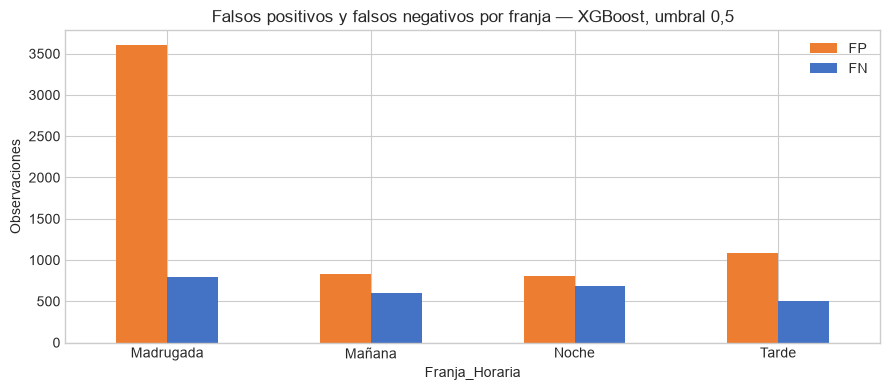

In [80]:
slot_errors = pd.DataFrame([
    {'Franja_Horaria': slot, 'Observaciones': len(part), 'Positivos_Reales': int(part.Alto_Riesgo.sum()),
     **classification_metrics(part.Alto_Riesgo, part.Prediccion, part.Probabilidad)}
    for slot, part in evaluation_xgb.groupby('Franja_Horaria')
])
slot_errors.to_csv(REPORTS_PATH / 'errores_xgboost_por_franja.csv', index=False)
display(slot_errors.round(4))
slot_errors.set_index('Franja_Horaria')[['FP','FN']].plot.bar(figsize=(9,4), color=['#ED7D31','#4472C4'])
plt.title('Falsos positivos y falsos negativos por franja — XGBoost, umbral 0,5')
plt.ylabel('Observaciones'); plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(REPORTS_PATH / '09_errores_por_franja.png', dpi=160, bbox_inches='tight')
plt.show()

La noche debe revisarse por la proporción de positivos omitidos. Los conteos y recall describen errores frente a la etiqueta histórica; no demuestran que una franja sea más peligrosa ni sustituyen el análisis de volumen y gravedad de accidentes.

## 19. Importancia por permutación exploratoria

In [81]:
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

sample = test.sample(n=min(5000, len(test)), random_state=42)
assert sample.Alto_Riesgo.nunique() == 2
# Pipeline ya ajustado: solo predict; no se llama fit sobre los artefactos.
original_pipeline = Pipeline([('preprocessor', pre_tree), ('model', models['XGBoost'])])
permutation = permutation_importance(original_pipeline, sample[feature_cols], sample.Alto_Riesgo,
    scoring='average_precision', n_repeats=3, random_state=42, n_jobs=1)
permutation_table = pd.DataFrame({'Variable': feature_cols,
    'Caida_AP_Media': permutation.importances_mean, 'Desviacion_Entre_Repeticiones': permutation.importances_std
}).sort_values('Caida_AP_Media', ascending=False)
permutation_table.to_csv(REPORTS_PATH / 'importancia_permutacion_xgboost.csv', index=False)
print('Muestra:', len(sample), 'positivos:', int(sample.Alto_Riesgo.sum()))
display(permutation_table.round(5))

Muestra: 5000 positivos: 332


,Variable,Caida_AP_Media,Desviacion_Entre_Repeticiones
0,Localidad,0.05166,0.00147
1,Franja_Horaria,0.04928,0.00194
7,Accidentes_Prom_30d,0.01306,0.00732
6,Accidentes_Prom_7d,0.01077,0.00431
4,Es_Fin_de_Semana,0.01048,0.00366
2,Dia_Semana,0.00568,0.00449
8,Accidentes_Semana_Anterior,0.00180,0.00054
5,Es_Festivo,0.00162,0.00121
9,Sin_Historial_Accidentes_Prom_7d,0.00000,0.00000
10,Sin_Historial_Accidentes_Prom_30d,0.00000,0.00000


La importancia interna no representa causalidad ni porcentaje de accidentes explicado y puede favorecer variables que separan grupos muy diferentes. La permutación mide caída de Average Precision al desordenar cada predictor original en una muestra reproducible de 5.000 observaciones, con tres repeticiones para limitar el costo. La desviación entre repeticiones no es un intervalo de confianza. Variables correlacionadas e históricos territoriales pueden compartir información; las permutaciones también pueden producir combinaciones poco realistas. Valores negativos no demuestran que una variable sea perjudicial.

## 20. Validación temporal expansiva 2018–2022

Se reemplaza la validación aleatoria del Notebook 04 por tres cortes que respetan el orden temporal: 2018–2019 → 2020, 2018–2020 → 2021 y 2018–2021 → 2022. En cada corte se vuelven a ajustar el preprocesador y el modelo usando solamente el pasado. El percentil 66 que define `Alto_Riesgo` también se calcula solo con el entrenamiento de cada corte y se aplica al año validado. Los modelos temporales son experimentales y no sobrescriben los archivos de `models/`.

In [82]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline

temporal_folds = [
    ('2018-2019', 2019, 2020),
    ('2018-2020', 2020, 2021),
    ('2018-2021', 2021, 2022),
]
group_cols = ['Localidad', 'Franja_Horaria']

def apply_past_target(train_part, validation_part):
    fold_thresholds = (train_part.groupby(group_cols, observed=True)['Num_Accidentes']
                       .quantile(2 / 3).rename('Umbral_Etiqueta').reset_index())
    train_labeled = train_part.merge(fold_thresholds, on=group_cols, how='left', validate='many_to_one')
    val_labeled = validation_part.merge(fold_thresholds, on=group_cols, how='left', validate='many_to_one')
    assert train_labeled['Umbral_Etiqueta'].notna().all()
    assert val_labeled['Umbral_Etiqueta'].notna().all()
    y_train_local = (train_labeled.Num_Accidentes > train_labeled.Umbral_Etiqueta).astype(int)
    y_val_local = (val_labeled.Num_Accidentes > val_labeled.Umbral_Etiqueta).astype(int)
    return train_labeled, val_labeled, y_train_local, y_val_local

pd.DataFrame(temporal_folds, columns=['Entrenamiento', 'Fin_Train', 'Validacion'])

,Entrenamiento,Fin_Train,Validacion
0,2018-2019,2019,2020
1,2018-2020,2020,2021
2,2018-2021,2021,2022


### 20.1 Entrenamiento y predicciones fuera de muestra

Se conservan los hiperparámetros del Notebook 04. `class_weight='balanced'` se adapta automáticamente a cada entrenamiento; `scale_pos_weight` se recalcula para XGBoost en cada corte.

In [83]:
temporal_rows, temporal_prediction_frames = [], []
for fold_number, (train_label, train_end, validation_year) in enumerate(temporal_folds, 1):
    train_fold = dataset[dataset.Fecha_Acc.dt.year <= train_end].copy()
    val_fold = dataset[dataset.Fecha_Acc.dt.year == validation_year].copy()
    train_fold, val_fold, y_train_fold, y_val_fold = apply_past_target(train_fold, val_fold)
    X_train_fold, X_val_fold = train_fold[feature_cols], val_fold[feature_cols]
    scale_fold = (y_train_fold == 0).sum() / (y_train_fold == 1).sum()
    fold_pipelines = {
        'Regresión Logística': Pipeline([('pre', clone(pre_log)), ('model', clone(models['Regresión Logística']))]),
        'Random Forest': Pipeline([('pre', clone(pre_tree)), ('model', clone(models['Random Forest']))]),
        'XGBoost': Pipeline([('pre', clone(pre_tree)), ('model', clone(models['XGBoost']).set_params(scale_pos_weight=scale_fold))]),
    }
    print(f'Corte {fold_number}: {train_label} → {validation_year} | train={len(train_fold):,}, validación={len(val_fold):,}')
    for model_name, pipeline in fold_pipelines.items():
        pipeline.fit(X_train_fold, y_train_fold)
        probability = pipeline.predict_proba(X_val_fold)[:, 1]
        prediction = (probability >= 0.5).astype(int)
        temporal_rows.append({
            'Corte': fold_number, 'Entrenamiento': train_label, 'Anio_Validacion': validation_year,
            'Modelo': model_name, 'N_Train': len(train_fold), 'N_Validacion': len(val_fold),
            'Prevalencia_Train': y_train_fold.mean(), 'Prevalencia_Validacion': y_val_fold.mean(),
            **classification_metrics(y_val_fold, prediction, probability)})
        temporal_prediction_frames.append(pd.DataFrame({
            'Corte': fold_number, 'Entrenamiento': train_label, 'Anio_Validacion': validation_year,
            'Modelo': model_name, 'Fecha_Acc': val_fold.Fecha_Acc.to_numpy(),
            'Localidad': val_fold.Localidad.to_numpy(), 'Franja_Horaria': val_fold.Franja_Horaria.to_numpy(),
            'Umbral_Etiqueta': val_fold.Umbral_Etiqueta.to_numpy(), 'Alto_Riesgo': y_val_fold.to_numpy(),
            'Probabilidad': probability, 'Prediccion_05': prediction}))

temporal_metrics = pd.DataFrame(temporal_rows)
temporal_oof = pd.concat(temporal_prediction_frames, ignore_index=True)
print('Validación temporal completada.')

Corte 1: 2018-2019 → 2020 | train=58,400, validación=29,280
Corte 2: 2018-2020 → 2021 | train=87,680, validación=29,200
Corte 3: 2018-2021 → 2022 | train=116,880, validación=29,200
Validación temporal completada.


### 20.2 Resultados por corte y estabilidad temporal

In [84]:
temporal_metric_cols = ['F1', 'AUC_ROC', 'Average_Precision', 'Precision', 'Recall', 'Brier']
temporal_summary = (temporal_metrics.groupby('Modelo')[temporal_metric_cols]
                    .agg(['mean', 'std'])
                    .sort_values(('Average_Precision', 'mean'), ascending=False))
temporal_metrics.to_csv(REPORTS_PATH / 'validacion_temporal_2018_2022_detalle.csv', index=False, encoding='utf-8-sig')
temporal_summary.to_csv(REPORTS_PATH / 'validacion_temporal_2018_2022_resumen.csv', encoding='utf-8-sig')
temporal_oof.to_parquet(REPORTS_PATH / 'predicciones_validacion_temporal_2020_2022.parquet', index=False)
display(temporal_metrics[['Entrenamiento', 'Anio_Validacion', 'Modelo', 'Prevalencia_Train',
                          'Prevalencia_Validacion', *temporal_metric_cols]].round(4))
display(temporal_summary.round(4))

,Entrenamiento,Anio_Validacion,Modelo,Prevalencia_Train,Prevalencia_Validacion,F1,AUC_ROC,Average_Precision,Precision,Recall,Brier
0,2018-2019,2020,Regresión Logística,0.1967,0.0998,0.2232,0.6330,0.1543,0.1363,0.6166,0.2249
1,2018-2019,2020,Random Forest,0.1967,0.0998,0.2406,0.6640,0.1719,0.1530,0.5632,0.2140
2,2018-2019,2020,XGBoost,0.1967,0.0998,0.2289,0.6406,0.1508,0.1456,0.5344,0.2119
3,2018-2020,2021,Regresión Logística,0.1882,0.1627,0.3351,0.6586,0.2643,0.2332,0.5947,0.2205
4,2018-2020,2021,Random Forest,0.1882,0.1627,0.3498,0.6830,0.2726,0.2454,0.6084,0.2185
5,2018-2020,2021,XGBoost,0.1882,0.1627,0.3508,0.6731,0.2649,0.2535,0.5694,0.2062
6,2018-2021,2022,Regresión Logística,0.1832,0.1434,0.3004,0.6394,0.2122,0.2050,0.5615,0.2162
7,2018-2021,2022,Random Forest,0.1832,0.1434,0.3113,0.6630,0.2291,0.2135,0.5746,0.2188
8,2018-2021,2022,XGBoost,0.1832,0.1434,0.3194,0.6684,0.2380,0.2216,0.5715,0.2075


F1         AUC_ROC         Average_Precision          \
                       mean     std    mean     std              mean     std   
Modelo                                                                          
Random Forest        0.3006  0.0554  0.6700  0.0113            0.2245  0.0505   
XGBoost              0.2997  0.0633  0.6607  0.0176            0.2179  0.0597   
Regresión Logística  0.2862  0.0572  0.6437  0.0133            0.2103  0.0550   

                    Precision          Recall           Brier          
                         mean     std    mean     std    mean     std  
Modelo                                                                 
Random Forest          0.2040  0.0469  0.5821  0.0235  0.2171  0.0027  
XGBoost                0.2069  0.0554  0.5585  0.0209  0.2086  0.0030  
Regresión Logística    0.1915  0.0499  0.5909  0.0277  0.2205  0.0043

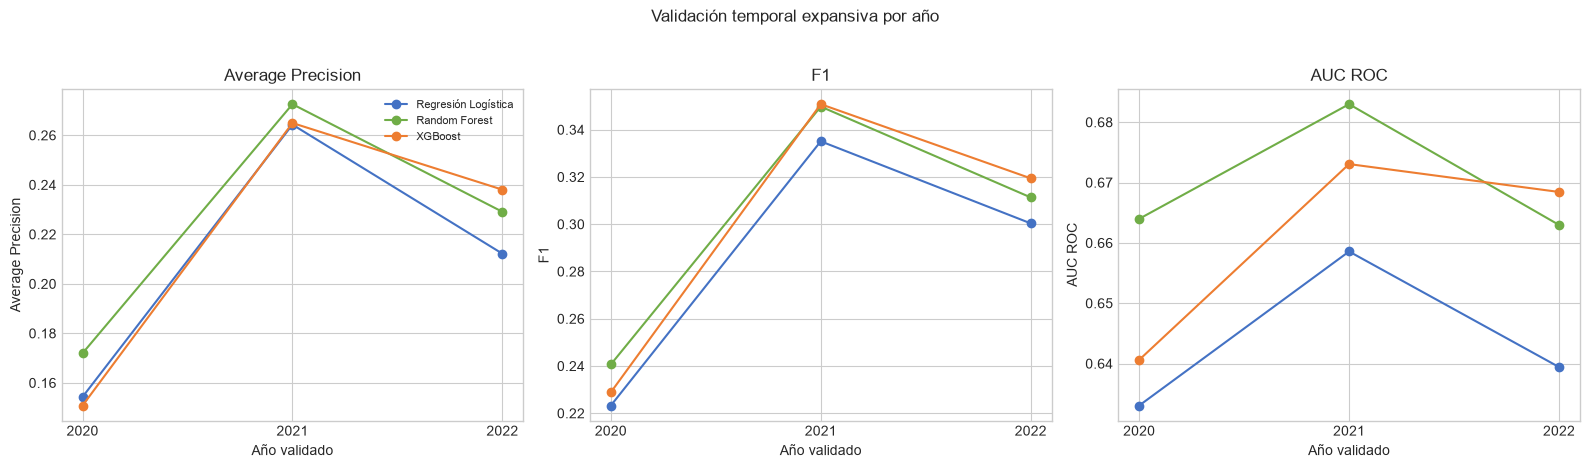

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric in zip(axes, ['Average_Precision', 'F1', 'AUC_ROC']):
    pivot = temporal_metrics.pivot(index='Anio_Validacion', columns='Modelo', values=metric)
    pivot[model_names].plot(marker='o', ax=ax, color=[colors[name] for name in model_names])
    ax.set(title=metric.replace('_', ' '), xlabel='Año validado', ylabel=metric.replace('_', ' '))
    ax.set_xticks([2020, 2021, 2022])
    if ax is not axes[0]: ax.get_legend().remove()
axes[0].legend(fontsize=8)
plt.suptitle('Validación temporal expansiva por año', y=1.03)
plt.tight_layout()
plt.savefig(REPORTS_PATH / '10_validacion_temporal_2018_2022.png', dpi=160, bbox_inches='tight')
plt.show()

### 20.3 Selección del algoritmo y del umbral

El algoritmo se selecciona por el promedio de `Average_Precision`, apropiado para la clase positiva minoritaria. Su umbral candidato se selecciona agregando exclusivamente las predicciones fuera de muestra de 2020–2022. Maximizar F1 es un criterio técnico; el umbral operativo deberá considerar los costos de falsas alertas y casos omitidos.

In [86]:
best_temporal_model = temporal_summary.index[0]
best_oof = temporal_oof[temporal_oof.Modelo.eq(best_temporal_model)].copy()
validation_threshold_rows = []
for threshold in np.linspace(0.05, 0.95, 181):
    pred = (best_oof.Probabilidad.to_numpy() >= threshold).astype(int)
    validation_threshold_rows.append({'Umbral': threshold,
        **classification_metrics(best_oof.Alto_Riesgo, pred, best_oof.Probabilidad)})
validation_threshold_table = pd.DataFrame(validation_threshold_rows)
candidate_threshold = float(validation_threshold_table.loc[validation_threshold_table.F1.idxmax(), 'Umbral'])
validation_threshold_table.to_csv(REPORTS_PATH / 'umbral_validacion_temporal_2020_2022.csv', index=False, encoding='utf-8-sig')
candidate_row = validation_threshold_table.loc[validation_threshold_table.Umbral.eq(candidate_threshold)].iloc[0]
default_row = validation_threshold_table.iloc[(validation_threshold_table.Umbral - 0.5).abs().argmin()]
print('Modelo seleccionado por Average Precision temporal:', best_temporal_model)
print(f'Umbral candidato seleccionado con 2020–2022: {candidate_threshold:.3f}')
display(pd.DataFrame({'Umbral 0.5': default_row, f'Umbral {candidate_threshold:.3f}': candidate_row}).T
        [['F1', 'Precision', 'Recall', 'Especificidad', 'FP', 'FN', 'TP', 'TN']].round(4))

Modelo seleccionado por Average Precision temporal: Random Forest
Umbral candidato seleccionado con 2020–2022: 0.525


,F1,Precision,Recall,Especificidad,FP,FN,TP,TN
Umbral 0.5,0.3041,0.2054,0.5853,0.6458,26857.0,4918.0,6942.0,48963.0
Umbral 0.525,0.3071,0.2177,0.5212,0.7070,22212.0,5679.0,6181.0,53608.0


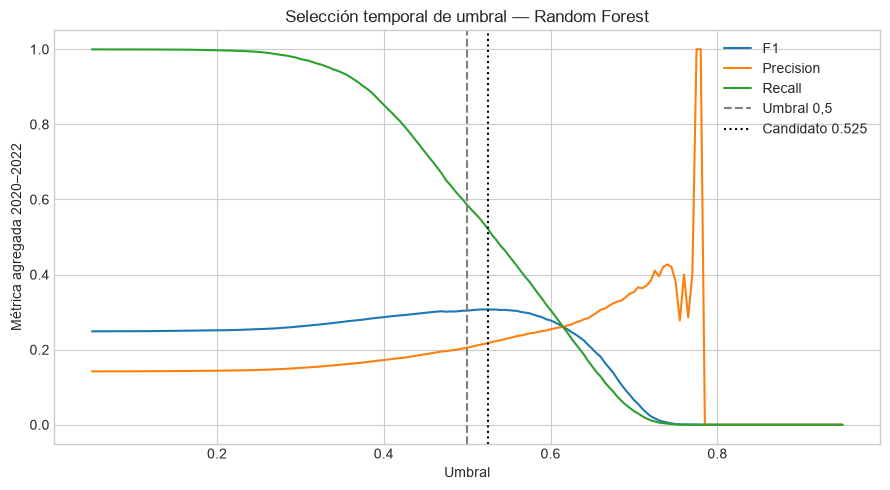

In [87]:
plt.figure(figsize=(9, 5))
for metric in ['F1', 'Precision', 'Recall']:
    plt.plot(validation_threshold_table.Umbral, validation_threshold_table[metric], label=metric)
plt.axvline(0.5, linestyle='--', color='gray', label='Umbral 0,5')
plt.axvline(candidate_threshold, linestyle=':', color='black', label=f'Candidato {candidate_threshold:.3f}')
plt.xlabel('Umbral'); plt.ylabel('Métrica agregada 2020–2022')
plt.title(f'Selección temporal de umbral — {best_temporal_model}')
plt.legend(); plt.tight_layout()
plt.savefig(REPORTS_PATH / '11_umbral_validacion_temporal.png', dpi=160, bbox_inches='tight')
plt.show()

### 20.4 Confirmación retrospectiva en 2023–2024

El algoritmo y el umbral de esta comparación proceden solamente de 2020–2022. Se aplican al modelo guardado, entrenado con 2018–2022. Sin embargo, 2023–2024 no recupera la condición de prueba intacta porque ya se consultó en etapas anteriores.

In [88]:
retrospective_score = scores[best_temporal_model]
retrospective_confirmation = pd.DataFrame({
    'Umbral_0.5': classification_metrics(y_test, (retrospective_score >= 0.5).astype(int), retrospective_score),
    f'Umbral_temporal_{candidate_threshold:.3f}': classification_metrics(
        y_test, (retrospective_score >= candidate_threshold).astype(int), retrospective_score)
}).T
retrospective_confirmation.insert(0, 'Modelo', best_temporal_model)
retrospective_confirmation.to_csv(REPORTS_PATH / 'confirmacion_retrospectiva_modelo_umbral_temporal.csv', encoding='utf-8-sig')
retrospective_confirmation.round(4)

,Modelo,F1,AUC_ROC,Average_Precision,Precision,Recall,Especificidad,Balanced_Accuracy,Brier,Tasa_Predicha_Positiva,TN,FP,FN,TP
Umbral_0.5,Random Forest,0.1551,0.6506,0.1053,0.1071,0.2809,0.8424,0.5616,0.1714,0.1654,46156.0,8636.0,2652.0,1036.0
Umbral_temporal_0.525,Random Forest,0.1505,0.6506,0.1053,0.1150,0.2177,0.8872,0.5525,0.1714,0.1194,48614.0,6178.0,2885.0,803.0


La media entre cortes mide el desempeño esperado y la desviación muestra estabilidad temporal. El mejor algoritmo no debe elegirse por un solo año. Una caída en un corte exige revisar prevalencia, cobertura y variables antes de atribuirla al modelo. La confirmación definitiva requerirá datos posteriores que no hayan intervenido en ninguna decisión.

## 21. Conclusión ejecutiva basada en los resultados calculados

In [89]:
from IPython.display import Markdown
best_relative = comparison.drop(index='Línea base').Average_Precision.idxmax()
temporal_ap = temporal_summary[('Average_Precision', 'mean')]
temporal_ap_std = temporal_summary[('Average_Precision', 'std')]
x = comparison.loc['XGBoost']; base = comparison.loc['Línea base']
s0, s1 = sensitivity_sumapaz.iloc[0], sensitivity_sumapaz.iloc[1]
night = slot_errors.set_index('Franja_Horaria').loc['Noche']
exp = sensitivity_no_locality.iloc[1]
executive = f"""**Resultado relativo.** {best_relative} obtiene la mayor Average Precision. XGBoost alcanza F1={x.F1:.4f}, AUC-ROC={x.AUC_ROC:.4f} y AP={x.Average_Precision:.4f}, frente a AP={base.Average_Precision:.4f} de la línea base. Presenta discriminación moderada, sin demostrar utilidad operativa suficiente.

**Validación temporal 2018–2022.** Al ajustar desde cero cada corte expansivo, {best_temporal_model} obtiene la mayor AP promedio ({temporal_ap[best_temporal_model]:.4f} ± {temporal_ap_std[best_temporal_model]:.4f}), frente a XGBoost ({temporal_ap['XGBoost']:.4f} ± {temporal_ap_std['XGBoost']:.4f}) y Regresión Logística ({temporal_ap['Regresión Logística']:.4f} ± {temporal_ap_std['Regresión Logística']:.4f}). El umbral candidato seleccionado solo con predicciones fuera de muestra de 2020–2022 es {candidate_threshold:.3f}. Este resultado cambia la selección preliminar: XGBoost domina la comparación retrospectiva 2023–2024, pero Random Forest muestra la mejor generalización temporal interna promedio.

**Alertas y omisiones.** Con umbral 0,5, la precisión es {x.Precision:.2%} y el recall {x.Recall:.2%}: {int(x.TP):,} verdaderos positivos, {int(x.FP):,} falsas alertas y {int(x.FN):,} positivos omitidos.

**Calibración.** El score medio de XGBoost es {np.mean(score_xgb):.2%}, frente a prevalencia observada {y_test.mean():.2%}. Su Brier={x.Brier:.4f}, frente a {base.Brier:.4f} de la constante de entrenamiento, evidencia junto con la curva limitaciones de calibración. La línea base también está afectada por el cambio de prevalencia.

**Estabilidad.** El F1 anual de XGBoost es {metrics_by_year.query("Modelo == 'XGBoost'").set_index('Anio').F1.to_dict()}. El F1 territorial varía entre {by_locality.F1.min():.4f} y {by_locality.F1.max():.4f}; el macro es {by_locality.F1.mean():.4f}. En noche se omiten {int(night.FN)} de {int(night.Positivos_Reales)} positivos (recall={night.Recall:.2%}). Los grupos tienen prevalencias diferentes y algunos muy pocos positivos; esto no mide peligrosidad.

**Sensibilidad territorial.** Excluir Sumapaz de la evaluación cambia AUC de {s0.AUC_ROC:.4f} a {s1.AUC_ROC:.4f}; su importancia puede reflejar un grupo casi siempre negativo. Sin Localidad explícita, el modelo experimental obtiene AUC={exp.AUC_ROC:.4f}, AP={exp.Average_Precision:.4f}, F1={exp.F1:.4f}. La comparación muestra sensibilidad territorial, no causalidad; persiste información geográfica indirecta.

**Umbral.** Pasar de 0,5 a 0,455 en 2024 agrega {delta_tp} positivos detectados y {delta_fp} falsas alertas, {ratio_alertas:.2f} por positivo adicional. El 0,455 es exploratorio y no definitivo.

**Alcance.** La validación temporal expansiva ya ajusta umbrales de etiqueta, preprocesamiento y entrenamiento dentro del pasado permitido de cada corte. Aun así, 2023–2024 ya se utilizó para comparar algoritmos, por lo que la confirmación sobre esos años sigue siendo retrospectiva y no independiente. Los históricos de prueba suponen disponibilidad diaria de accidentes pasados: esta evaluación no valida pronósticos de múltiples días sin actualizar historial.

**Dashboard.** XGBoost funciona mejor como herramienta exploratoria de priorización relativa que como generador de probabilidades confiables. Mostrar puntuaciones relativas con sus limitaciones, no probabilidades literales. No se considera listo para producción; se requieren un criterio operativo y una evaluación posterior independiente.
"""
display(Markdown(executive))
(REPORTS_PATH / 'conclusion_ejecutiva.md').write_text(executive, encoding='utf-8')

**Resultado relativo.** XGBoost obtiene la mayor Average Precision. XGBoost alcanza F1=0.1973, AUC-ROC=0.7053 y AP=0.1329, frente a AP=0.0631 de la línea base. Presenta discriminación moderada, sin demostrar utilidad operativa suficiente.

**Validación temporal 2018–2022.** Al ajustar desde cero cada corte expansivo, Random Forest obtiene la mayor AP promedio (0.2245 ± 0.0505), frente a XGBoost (0.2179 ± 0.0597) y Regresión Logística (0.2103 ± 0.0550). El umbral candidato seleccionado solo con predicciones fuera de muestra de 2020–2022 es 0.525. Este resultado cambia la selección preliminar: XGBoost domina la comparación retrospectiva 2023–2024, pero Random Forest muestra la mejor generalización temporal interna promedio.

**Alertas y omisiones.** Con umbral 0,5, la precisión es 14.76% y el recall 29.72%: 1,096 verdaderos positivos, 6,328 falsas alertas y 2,592 positivos omitidos.

**Calibración.** El score medio de XGBoost es 29.23%, frente a prevalencia observada 6.31%. Su Brier=0.1264, frente a 0.0726 de la constante de entrenamiento, evidencia junto con la curva limitaciones de calibración. La línea base también está afectada por el cambio de prevalencia.

**Estabilidad.** El F1 anual de XGBoost es {2023: 0.19350232059978578, 2024: 0.20108892921960073}. El F1 territorial varía entre 0.0000 y 0.2872; el macro es 0.1524. En noche se omiten 689 de 765 positivos (recall=9.93%). Los grupos tienen prevalencias diferentes y algunos muy pocos positivos; esto no mide peligrosidad.

**Sensibilidad territorial.** Excluir Sumapaz de la evaluación cambia AUC de 0.7053 a 0.6891; su importancia puede reflejar un grupo casi siempre negativo. Sin Localidad explícita, el modelo experimental obtiene AUC=0.5887, AP=0.0798, F1=0.1347. La comparación muestra sensibilidad territorial, no causalidad; persiste información geográfica indirecta.

**Umbral.** Pasar de 0,5 a 0,455 en 2024 agrega 176 positivos detectados y 1523 falsas alertas, 8.65 por positivo adicional. El 0,455 es exploratorio y no definitivo.

**Alcance.** La validación temporal expansiva ya ajusta umbrales de etiqueta, preprocesamiento y entrenamiento dentro del pasado permitido de cada corte. Aun así, 2023–2024 ya se utilizó para comparar algoritmos, por lo que la confirmación sobre esos años sigue siendo retrospectiva y no independiente. Los históricos de prueba suponen disponibilidad diaria de accidentes pasados: esta evaluación no valida pronósticos de múltiples días sin actualizar historial.

**Dashboard.** XGBoost funciona mejor como herramienta exploratoria de priorización relativa que como generador de probabilidades confiables. Mostrar puntuaciones relativas con sus limitaciones, no probabilidades literales. No se considera listo para producción; se requieren un criterio operativo y una evaluación posterior independiente.


2828

La conclusión anterior se genera con las tablas de esta ejecución para evitar cifras desactualizadas. Las comparaciones sin intervalos de incertidumbre no demuestran significancia estadística; una siguiente fase puede incorporar remuestreo por bloques de fechas.